In [9]:
import zipfile
import pandas as pd

with zipfile.ZipFile("Air Quality Data in India (2015 - 2020) archive (4).zip", 'r') as z:
    print(z.namelist())   # Step 1: see file names
    z.extractall()        # Step 2: extract

df = pd.read_csv("city_day.csv")
df.head()

['city_day.csv', 'city_hour.csv', 'station_day.csv', 'station_hour.csv', 'stations.csv']


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [10]:
df.columns

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [20]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,29531.000000,29531.000000,29531.00000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000
mean,67.450578,118.127103,17.57473,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,59.414476,71.500953,21.35922,22.941051,29.317936,20.711370,6.715753,16.909088,20.163443,14.226364,17.034769,3.932426,129.064348
min,0.040000,0.010000,0.02000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,32.150000,79.315000,6.21000,12.980000,14.670000,12.040000,0.540000,6.090000,20.740000,0.240000,1.280000,2.000000,88.000000
50%,58.030000,118.127103,11.53000,25.240000,27.550000,23.483476,0.950000,10.480000,34.491430,1.840000,6.930000,3.070128,138.000000
75%,72.450000,118.127103,17.57473,34.665000,36.015000,23.483476,1.710000,14.531977,42.730000,3.280840,8.700972,3.070128,179.000000
max,949.990000,1000.000000,390.68000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [12]:
df.isnull().sum()

,0
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


# 1.Handle Missing Values

In [14]:
# Option 1: Fill with mean (for numerical columns)
df.fillna(df.mean(numeric_only=True), inplace=True)


In [16]:
# Option 2: Forward fill (good for time series)
df.fillna(method="ffill",inplace=True)

/tmp/ipykernel_3439/3165783841.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill",inplace=True)


In [17]:
df.isnull().sum()

,0
City,0
Date,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0
SO2,0


# Fill Numerical Columns (use MEDIAN)

In [22]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill Categorical Columns (use MODE)

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [24]:
df.isnull().sum()

,0
City,0
Date,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0
SO2,0


In [25]:
df['AQI_Bucket'].fillna(df['AQI_Bucket'].mode()[0], inplace=True)

In [27]:
df.isnull().sum()

,0
City,0
Date,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0
SO2,0


# Remove Duplicates

In [18]:
df.drop_duplicates(inplace=True)

In [19]:
df.isnull().sum()

,0
City,0
Date,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0
SO2,0


In [28]:
print(df.duplicated().sum())

0


In [29]:
df.dtypes

,0
City,object
Date,object
PM2.5,float64
PM10,float64
NO,float64
NO2,float64
NOx,float64
NH3,float64
CO,float64
SO2,float64


# Convert Date Column

In [ ]:
df["Day"]=pd.to_datetime(df["Day"])
df.set_index("Date",inplace=True)

# Handle Outliers

# Step 1: IQR Method

In [33]:
def find_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(f"{column}")
    print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"Lower={lower:.2f}, Upper={upper:.2f}")

    outliers = df[(df[column] < lower) | (df[column] > upper)]
    print("Outliers count:", outliers.shape[0])
    print("-----------------------------------")

    return outliers

Step 2: Apply on Important Columns

In [34]:
find_outliers(df, "AQI")
find_outliers(df, "PM2.5")
find_outliers(df, "PM10")

AQI
Q1=88.00, Q3=179.00, IQR=91.00
Lower=-48.50, Upper=315.50
Outliers count: 3192
-----------------------------------
PM2.5
Q1=32.15, Q3=72.45, IQR=40.30
Lower=-28.30, Upper=132.90
Outliers count: 2736
-----------------------------------
PM10
Q1=79.31, Q3=118.13, IQR=38.81
Lower=21.10, Upper=176.35
Outliers count: 3776
-----------------------------------


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
1606,Ahmedabad,2019-05-26,63.15,177.87,28.03,100.08,80.78,23.483476,28.03,122.43,50.32,17.05,84.59,13.16,558.0,Severe
1664,Ahmedabad,2019-07-23,73.98,202.30,17.81,168.45,107.32,23.483476,17.81,35.04,70.30,6.30,80.04,1.48,587.0,Severe
1678,Ahmedabad,2019-08-06,50.53,181.39,38.94,57.64,70.29,23.483476,38.94,39.45,41.18,2.14,32.05,0.52,564.0,Severe
1679,Ahmedabad,2019-08-07,60.09,199.34,40.91,30.12,60.02,23.483476,40.91,40.22,26.52,2.14,32.05,0.52,545.0,Severe
1680,Ahmedabad,2019-08-08,57.61,195.84,35.46,47.73,62.52,23.483476,35.46,39.76,37.96,2.12,31.72,0.51,530.0,Severe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29371,Visakhapatnam,2020-01-24,74.82,177.62,16.76,48.23,39.27,12.040000,1.43,7.31,40.41,6.73,14.80,3.10,156.0,Moderate
29391,Visakhapatnam,2020-02-13,84.11,179.96,20.69,63.84,50.78,14.850000,1.33,8.97,32.44,6.16,15.04,6.35,150.0,Moderate
29484,Visakhapatnam,2020-05-16,2.00,17.99,1.29,10.24,6.11,9.480000,0.11,8.86,19.75,0.73,1.80,0.41,32.0,Good
29485,Visakhapatnam,2020-05-17,6.30,17.76,1.09,12.21,7.07,7.400000,0.11,8.56,17.14,0.86,6.90,0.29,23.0,Good


Step 3: Boxplot Visualization

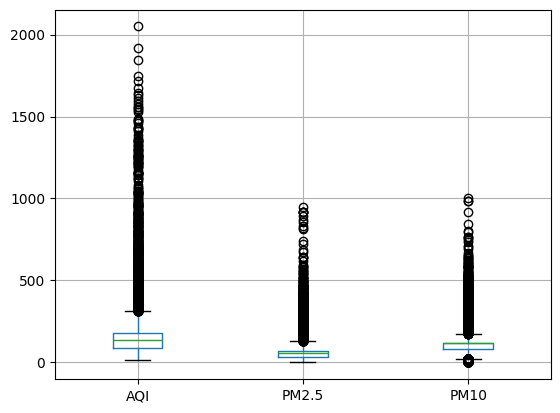

In [35]:
import matplotlib.pyplot as plt

df.boxplot(column=["AQI", "PM2.5", "PM10"])
plt.show()

In [38]:
Q1 = df["AQI"].quantile(0.25)
Q3 = df["AQI"].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df["AQI"] < (Q1 - 1.5 * IQR)) | (df["AQI"] > (Q3 + 1.5 * IQR)))]

2. Line Plot (Time Series Insight)

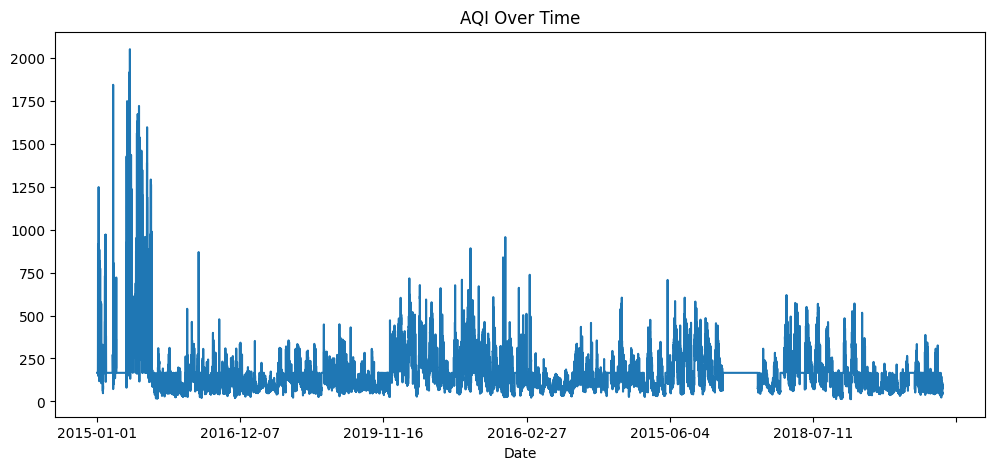

In [36]:
df.set_index('Date', inplace=True)

df['AQI'].plot(figsize=(12,5), title="AQI Over Time")
plt.show()

3. Histogram (Distribution)

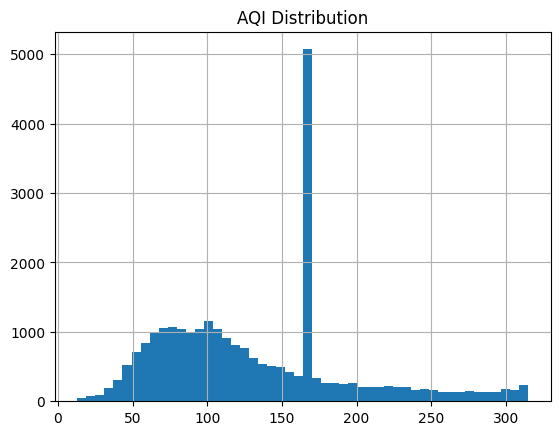

In [39]:
df['AQI'].hist(bins=50)
plt.title("AQI Distribution")
plt.show()

4. Heatmap (Advanced Insight)

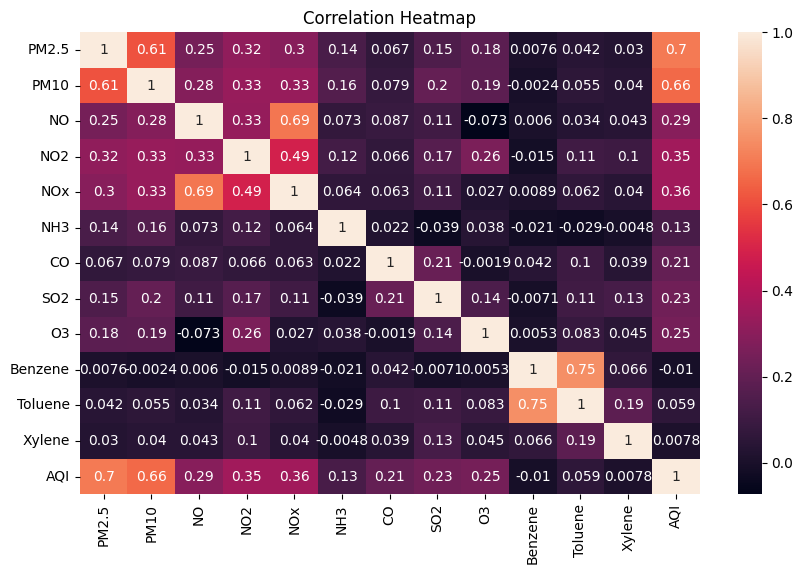

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
corr = df.select_dtypes(include=['number']).corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [45]:
df.columns

Index(['City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
       'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

# STEP 7: Feature Engineering

Now apply Feature Engineering

In [47]:
df.index = pd.to_datetime(df.index)

In [48]:
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Day'] = df.index.day

In [49]:
# Average Pollution
df['Avg_Pollution'] = df[['PM2.5','PM10','NO2','SO2','CO']].mean(axis=1)

# Pollution Level
df['Pollution_Level'] = pd.cut(
    df['AQI'],
    bins=[0, 50, 100, 200, 300, 500],
    labels=['Good','Satisfactory','Moderate','Poor','Severe']
)

# High Pollution Flag
df['High_Pollution'] = df['AQI'].apply(lambda x: 1 if x > 200 else 0)

In [50]:
df.head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,...,Toluene,Xylene,AQI,AQI_Bucket,Year,Month,Day,Avg_Pollution,Pollution_Level,High_Pollution
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,Ahmedabad,67.450578,118.127103,0.92,18.22,17.15,23.483476,0.92,27.64,133.36,...,0.02,0.00,166.463581,Unknown,2015,1,1,46.471536,Moderate,0
2015-01-02,Ahmedabad,67.450578,118.127103,0.97,15.69,16.46,23.483476,0.97,24.55,34.06,...,5.50,3.77,166.463581,Unknown,2015,1,2,45.357536,Moderate,0
2015-01-03,Ahmedabad,67.450578,118.127103,17.40,19.30,29.70,23.483476,17.40,29.07,30.70,...,16.40,2.25,166.463581,Unknown,2015,1,3,50.269536,Moderate,0
2015-01-04,Ahmedabad,67.450578,118.127103,1.70,18.48,17.97,23.483476,1.70,18.59,36.08,...,10.14,1.00,166.463581,Unknown,2015,1,4,44.869536,Moderate,0
2015-01-05,Ahmedabad,67.450578,118.127103,22.10,21.42,37.76,23.483476,22.10,39.33,39.31,...,18.89,2.78,166.463581,Unknown,2015,1,5,53.685536,Moderate,0


#STEP 8: Encoding

Label Encoding (for ordered data)

AQI_Bucket

In [51]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['AQI_Bucket_Encoded'] = le.fit_transform(df['AQI_Bucket'])

Pollution_Level

In [52]:
df['Pollution_Level_Encoded'] = le.fit_transform(df['Pollution_Level'])

One Hot Encoding (for City)

In [53]:
df = pd.get_dummies(df, columns=['City'], drop_first=True)

In [54]:
df.head()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,...,City_Jorapokhar,City_Kochi,City_Kolkata,City_Lucknow,City_Mumbai,City_Patna,City_Shillong,City_Talcher,City_Thiruvananthapuram,City_Visakhapatnam
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,67.450578,118.127103,0.92,18.22,17.15,23.483476,0.92,27.64,133.36,0.00,...,False,False,False,False,False,False,False,False,False,False
2015-01-02,67.450578,118.127103,0.97,15.69,16.46,23.483476,0.97,24.55,34.06,3.68,...,False,False,False,False,False,False,False,False,False,False
2015-01-03,67.450578,118.127103,17.40,19.30,29.70,23.483476,17.40,29.07,30.70,6.80,...,False,False,False,False,False,False,False,False,False,False
2015-01-04,67.450578,118.127103,1.70,18.48,17.97,23.483476,1.70,18.59,36.08,4.43,...,False,False,False,False,False,False,False,False,False,False
2015-01-05,67.450578,118.127103,22.10,21.42,37.76,23.483476,22.10,39.33,39.31,7.01,...,False,False,False,False,False,False,False,False,False,False


#STEP 9: Feature Scaling

Step 1: Select columns to scale

In [55]:
scale_cols = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3',
              'Benzene','Toluene','Xylene','AQI','Avg_Pollution']

Step 2: Apply StandardScaler

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = df.copy()

df_scaled[scale_cols] = scaler.fit_transform(df[scale_cols])

Step 3: Verify Scaling

In [57]:
df_scaled[scale_cols].describe().round(2)

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,Avg_Pollution
count,26339.00,26339.00,26339.00,26339.00,26339.00,26339.00,26339.00,26339.00,26339.00,26339.00,26339.00,26339.00,26339.00,26339.00
mean,0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.55,-2.00,-0.88,-1.44,-1.16,-1.08,-0.48,-0.99,-1.75,-0.21,-0.48,-0.83,-1.91,-2.16
25%,-0.69,-0.66,-0.53,-0.74,-0.60,-0.54,-0.30,-0.53,-0.69,-0.20,-0.40,-0.26,-0.80,-0.67
50%,-0.05,0.18,-0.25,-0.10,-0.13,0.04,-0.16,-0.21,0.03,-0.10,-0.08,0.04,-0.16,0.00
75%,0.37,0.18,0.17,0.30,0.14,0.04,0.04,0.15,0.41,0.01,0.09,0.04,0.53,0.36
max,25.59,16.49,22.41,12.30,17.74,15.86,46.62,14.15,7.18,30.59,29.06,47.65,2.90,19.24


In [58]:
df_scaled.head()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,...,City_Jorapokhar,City_Kochi,City_Kolkata,City_Lucknow,City_Mumbai,City_Patna,City_Shillong,City_Talcher,City_Thiruvananthapuram,City_Visakhapatnam
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,0.374853,0.183174,-0.823436,-0.402283,-0.469276,0.043604,-0.147388,1.170827,5.164745,-0.209253,...,False,False,False,False,False,False,False,False,False,False
2015-01-02,0.374853,0.183174,-0.820455,-0.546319,-0.497167,0.043604,-0.129559,0.929575,0.014044,0.039846,...,False,False,False,False,False,False,False,False,False,False
2015-01-03,0.374853,0.183174,0.159139,-0.340797,0.038015,0.043604,5.728909,1.282474,-0.160240,0.251038,...,False,False,False,False,False,False,False,False,False,False
2015-01-04,0.374853,0.183174,-0.776931,-0.387481,-0.436131,0.043604,0.130738,0.464247,0.118822,0.090613,...,False,False,False,False,False,False,False,False,False,False
2015-01-05,0.374853,0.183174,0.439363,-0.220103,0.363814,0.043604,7.404795,2.083525,0.286362,0.265253,...,False,False,False,False,False,False,False,False,False,False


#🔰 STEP 10: Final Dataset & Summary

Create Final Dataset

In [62]:
df_final = df_scaled.copy()

Drop unnecessary columns

In [63]:
df_final.drop(columns=['AQI_Bucket', 'Pollution_Level'], inplace=True)

Final Verification

In [64]:
print("Shape:", df_final.shape)
print("Missing values:", df_final.isnull().sum().sum())
print("Duplicates:", df_final.duplicated().sum())
print("Data types:\n", df_final.dtypes)
print("Statistics:\n", df_final.describe().round(2))
print("First rows:\n", df_final.head())

Shape: (26339, 45)
Missing values: 0
Duplicates: 0
Data types:
 PM2.5                      float64
PM10                       float64
NO                         float64
NO2                        float64
NOx                        float64
NH3                        float64
CO                         float64
SO2                        float64
O3                         float64
Benzene                    float64
Toluene                    float64
Xylene                     float64
AQI                        float64
Year                         int32
Month                        int32
Day                          int32
Avg_Pollution              float64
High_Pollution               int64
AQI_Bucket_Encoded           int64
Pollution_Level_Encoded      int64
City_Aizawl                   bool
City_Amaravati                bool
City_Amritsar                 bool
City_Bengaluru                bool
City_Bhopal                   bool
City_Brajrajnagar             bool
City_Chandigarh           